# Differentiate through an intermediate file

See also [Lukas Heinrich's slides](https://indico.cern.ch/event/960587/contributions/4070325/) from a 2020 IRIS-HEP blueprint workshop.

In [1]:
import jax
import jax.numpy as jnp
import jax.export
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.style.use("ggplot")

Define a simple pipeline:

data `x` -> `y = f_a(x, alpha, beta)` -> `result = f_b(y)`

In a physics context, these steps could e.g. correspond to computing an observable during `f_a` and binning it, then performing statistical inference during `f_b`.
`alpha` and `beta` are parameters which we may want to optimize.

In [2]:
x = jnp.array([1.0, 2.0, 3.0])  # data

def f_a(x, alpha, beta):
    return beta * x * alpha**3

def f_b(y):
    return jnp.sum(y)

pipeline = lambda alpha, beta: f_b(f_a(x, alpha, beta))  # full chain

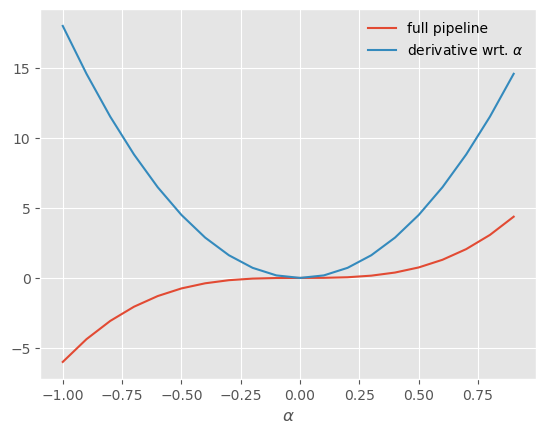

In [3]:
alphas = jnp.arange(-1, 1, 0.1)
beta = 1.0
fig, ax = plt.subplots()
ax.plot(alphas, jax.vmap(lambda t: pipeline(t, beta))(alphas), label="full pipeline")
ax.plot(alphas, jax.vmap(jax.grad(lambda t: pipeline(t, beta)))(alphas), label=r"derivative wrt. $\alpha$")
ax.set_xlabel(r"$\alpha$")
_ = ax.legend(frameon=False)

Lets differentiate through the full pipeline for $\alpha=0.5$.

In [4]:
alpha = 0.5
beta = 1.0

# gradient through full pipeline
jax.grad(pipeline, argnums=(0, 1))(alpha, beta)

(Array(4.5, dtype=float32, weak_type=True),
 Array(0.75, dtype=float32, weak_type=True))

Here is a more manual and explicit version with VJPs:

In [5]:
alpha = 0.5
beta = 1.0

# forward pass
y, vjp_a = jax.vjp(lambda alpha, beta: f_a(x, alpha, beta), alpha, beta)
z, vjp_b = jax.vjp(f_b, y)

# backward pass
v = jnp.array(1.0)
(dzdy,) = vjp_b(v)
(dz_dalpha, dz_dbeta) = vjp_a(dzdy)

print(f"dz/d(alpha) at alpha={alpha} is {dz_dalpha}")
print(f"dz/d(beta) at beta={beta} is {dz_dbeta}")

dz/d(alpha) at alpha=0.5 is 4.5
dz/d(beta) at beta=1.0 is 0.75


## With an intermediate file

Now do the same with a pipeline that goes through an intermediate file.
For a pipeline $(x, \alpha, \beta)$ -`f_a`-> $y$ -`f_b`-> $z$, we get $\frac{dz}{d\alpha} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial \alpha}$.

In [6]:
def forward_and_save_vjp(name, db, f, primals):
    """Run f forward, save its output and vjp, register to database."""
    output, vjp_fn = jax.vjp(f, *primals)
    output_file = f"{name}_result.npz"
    np.savez(output_file, output=np.asarray(output))

    vjp_file = f"{name}_vjp.jax"
    with open(vjp_file, "wb") as f:
        f.write(jax.export.export(jax.jit(vjp_fn))(jnp.ones_like(output)).serialize())

    db[name] = {"output": output_file, "vjp": vjp_file}
    return output, db


def load_output(name, db):
    """Load output of a step."""
    return jnp.array(np.load(db[name]["output"])["output"])


def load_and_apply_vjp(name, db, cotangent):
    """Load vjp, apply to cotangent vector, save, register to database."""
    with open(db[name]["vjp"], "rb") as f:
        vjp_fn = jax.export.deserialize(f.read())

    result = vjp_fn.call(cotangent)
    cotangent_file = f"{name}_cotangent.npz"
    np.savez(cotangent_file, **{f"grad_{i}": np.asarray(g) for i, g in enumerate(result)})
    db[name]["cotangent"] = cotangent_file
    return result, db


def load_cotangent(name, db):
    """Load cotangent result of a backward step."""
    data = np.load(db[name]["cotangent"])
    return tuple(jnp.array(data[k]) for k in sorted(data.files))

### Forward pass
#### Step 1: Run `f_a` forward and save output and `vjp` to disk

In [7]:
db = {}  # "database" keeping track of files on disk

alpha = 0.5
beta = 1.0
y, db = forward_and_save_vjp("f_a", db, lambda alpha, beta: f_a(x, alpha, beta), (alpha, beta))
print(f"result of first step forward pass: {y}")

result of first step forward pass: [0.125 0.25  0.375]


#### Step 2: Run `f_b` forward and save output and `vjp` to disk

In [8]:
y_from_disk = load_output("f_a", db)
z, db = forward_and_save_vjp("f_b", db, f_b, (y_from_disk,))
print(f"result of second step forward pass: {z}")

result of second step forward pass: 0.75


### Backward pass

Take user-provided vector `v` and go through the VJPs in reverse.

#### Step 3: Load `vjp` for `f_b` and compute $v^T \cdot \frac{\partial z}{\partial y}$

In [9]:
v = jnp.array(1.0)

(dzdy,), db = load_and_apply_vjp("f_b", db, v)
print(f"v^T * dz/dy = {dzdy}")

v^T * dz/dy = [1. 1. 1.]


The shape of `dzdy` exactly matches the shape of `y`, i.e. the shape of the output of `f_a` in the forward pass and the input to the backward pass of `f_a` match — even though we differentiate w.r.t. two parameters (`alpha` and `beta`). The number of parameters only affects what `vjp_a` *produces* (two gradients instead of one), not the cotangent that flows between stages.

This is a general feature of the approach. In practice it means that serialized exchange formats can re-use the same structure.
In an example where `f_a` produces a workspace, the exchange format of `f_b` -> `f_a` in the backward pass would be a "gradient" version of it with the same shape.

#### Step 4: Load `vjp` for `f_a` and compute $v^T \cdot \frac{dz}{d\alpha} = (v^T \cdot \frac{\partial z}{\partial y}) \cdot \frac{\partial y}{\partial \alpha}$

In [10]:
dzdy_from_disk, = load_cotangent("f_b", db)
(dz_dalpha, dz_dbeta), db = load_and_apply_vjp("f_a", db, dzdy_from_disk)
print(f"dz/dalpha at alpha={alpha} is {dz_dalpha}")
print(f"dz/dbeta at beta={beta} is {dz_dbeta}")

dz/dalpha at alpha=0.5 is 4.5
dz/dbeta at beta=1.0 is 0.75


## Distributed analysis

In [11]:
x = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])  # a very large amount of data 

This section compares processing all data `x` in bulk to a distributed setup that is more HEP-like, starting with the bulk approach.

In [12]:
alpha = 0.5
beta = 1.0

# forward pass
y, vjp_a = jax.vjp(lambda alpha, beta: f_a(x, alpha, beta), alpha, beta)
z, vjp_b = jax.vjp(f_b, y)

# backward pass
v = jnp.array(1.0)
(dzdy,) = vjp_b(v)
(dz_dalpha, dz_dbeta) = vjp_a(dzdy)

print(f"dz/d(alpha) at alpha={alpha} is {dz_dalpha}")
print(f"dz/d(beta) at beta={beta} is {dz_dbeta}")

dz/d(alpha) at alpha=0.5 is 41.25
dz/d(beta) at beta=1.0 is 6.875


Now process `f_a` in two batches over half of `x` each.

In [13]:
x1, x2 = x[:5], x[5:]

# forward pass in two batches
y1, vjp_a1 = jax.vjp(lambda alpha, beta: f_a(x1, alpha, beta), alpha, beta)  # run this on one worker
y2, vjp_a2 = jax.vjp(lambda alpha, beta: f_a(x2, alpha, beta), alpha, beta)  # run this on another worker

z1, vjp_b1 = jax.vjp(f_b, y1)  # can again split these two between workers
z2, vjp_b2 = jax.vjp(f_b, y2)
z = z1 + z2  # combine results

# backward pass in two batches
v = jnp.array(1.0)
(dzdy1,) = vjp_b1(v)  # can again split
(dzdy2,) = vjp_b2(v)

# depending on the problem, there may be a synchronization step needed here

(dz_dalpha_1, dz_dbeta_1) = vjp_a1(dzdy1)  # and another split
(dz_dalpha_2, dz_dbeta_2) = vjp_a2(dzdy2)

print(f"dz/d(alpha) at alpha={alpha} is {dz_dalpha_1 + dz_dalpha_2}")  # gradients sum
print(f"dz/d(beta) at beta={beta} is {dz_dbeta_1 + dz_dbeta_2}")

dz/d(alpha) at alpha=0.5 is 41.25
dz/d(beta) at beta=1.0 is 6.875


Distributing this through `dask` looks feasible.
We do need to write out the `vjp` functions per batch, so doing this efficiently may require some care.